<a href="https://colab.research.google.com/github/oyueo-mm/LVQ_by_entry/blob/main/LVQ.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np

# X 데이터
X = np.array([
[-215.4,-39.4], [-192.7,-22], [-155.9,-52.1], [-193.8,-91.5],
[-204.6,-50.2], [-157.4,-87], [-180.4,-63.2], [-209.5,-75.5],
[-164.4,-22], [-122.7,-37.2], [-128.7,-97.1], [-145.1,-119],

[169.5,-22.7], [141.2,-15.6], [122.9,-51.3], [91.3,-82.6],
[59.3,-109.4], [81.6,-116.4], [61.9,-71.4], [117,-13.4],
[151.2,-64.7], [187,-18.6], [212.3,-79.2], [127.8,-120.5],
[203.7,-106], [74.9,-32.4],

[-49.8,125], [-10.7,66.9], [61.9,124.2], [3.8,48],
[23.2,72.1], [43.3,97.1], [-29.3,96.3], [-10,116.8],
[-71.8,107.5], [11.6,93.7]
])

# y 라벨
y = np.array(
[1]*12 + [2]*14 + [3]*10
)

In [ ]:
import numpy as np

class LVQ:
    def __init__(self, n_prototypes_per_class=1, lr=0.1, epochs=100):
        """
        n_prototypes_per_class: 클래스당 prototype 개수
        lr: 학습률 (η)
        epochs: 반복 횟수
        """
        self.n_prototypes_per_class = n_prototypes_per_class
        self.lr = lr
        self.epochs = epochs

    def _initialize_prototypes(self, X, y):
        """
        각 클래스별로 prototype을 초기화
        → 해당 클래스 데이터 중 랜덤 선택
        """
        self.prototypes = []
        self.prototype_labels = []

        classes = np.unique(y)

        for c in classes:
            X_c = X[y == c]
            indices = np.random.choice(len(X_c), self.n_prototypes_per_class)

            for idx in indices:
                self.prototypes.append(X_c[idx])
                self.prototype_labels.append(c)

        self.prototypes = np.array(self.prototypes)
        self.prototype_labels = np.array(self.prototype_labels)

    def _find_closest_prototype(self, x):
        """
        가장 가까운 prototype 찾기
        """
        distances = np.linalg.norm(self.prototypes - x, axis=1)
        return np.argmin(distances)

    def fit(self, X, y):
        """
        LVQ 학습
        """
        self._initialize_prototypes(X, y)

        for epoch in range(self.epochs):
            for i in range(len(X)):
                x = X[i]
                label = y[i]

                # 1. 가장 가까운 prototype 찾기
                idx = self._find_closest_prototype(x)

                # 2. 업데이트
                if self.prototype_labels[idx] == label:
                    # 가까워짐
                    self.prototypes[idx] += self.lr * (x - self.prototypes[idx])
                else:
                    # 멀어짐
                    self.prototypes[idx] -= self.lr * (x - self.prototypes[idx])

    def predict(self, X):
        """
        예측
        """
        preds = []

        for x in X:
            idx = self._find_closest_prototype(x)
            preds.append(self.prototype_labels[idx])

        return np.array(preds)

In [ ]:
model = LVQ(n_prototypes_per_class=1, lr=0.05, epochs=100)

model.fit(X, y)

pred = model.predict(X)

In [ ]:
pred

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3])

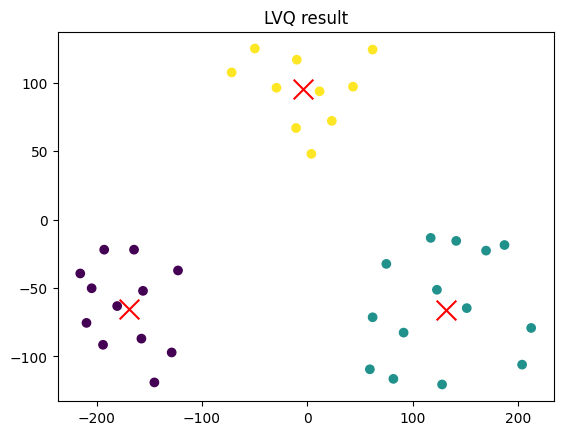

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(X[:,0], X[:,1], c=y, cmap='viridis')

# prototype 찍기
plt.scatter(model.prototypes[:,0],
            model.prototypes[:,1],
            c='red', marker='x', s=200)

plt.title("LVQ result")
plt.show()

# LVQ

In [ ]:
import numpy as np

X = np.array([
[-215.4,-39.4], [-192.7,-22], [-155.9,-52.1], [-193.8,-91.5],
[-204.6,-50.2], [-157.4,-87], [-180.4,-63.2], [-209.5,-75.5],
[-164.4,-22], [-122.7,-37.2], [-128.7,-97.1], [-145.1,-119],

[169.5,-22.7], [141.2,-15.6], [122.9,-51.3], [91.3,-82.6],
[59.3,-109.4], [81.6,-116.4], [61.9,-71.4], [117,-13.4],
[151.2,-64.7], [187,-18.6], [212.3,-79.2], [127.8,-120.5],
[203.7,-106], [74.9,-32.4],

[-49.8,125], [-10.7,66.9], [61.9,124.2], [3.8,48],
[23.2,72.1], [43.3,97.1], [-29.3,96.3], [-10,116.8],
[-71.8,107.5], [11.6,93.7]
])

y = np.array(
[1]*12 + [2]*14 + [3]*10
)

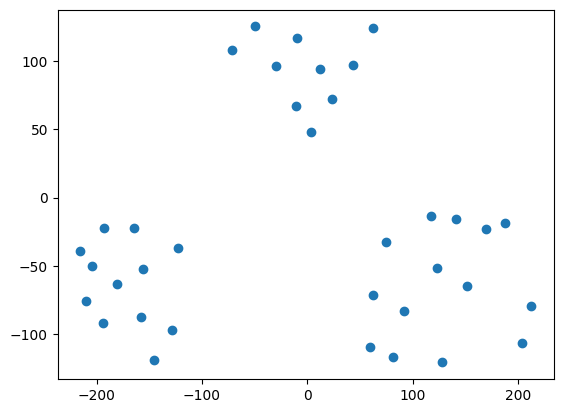

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(X[:, 0], X[:, 1])
plt.show()

In [ ]:
q = 3
prototype_vectors = []
prototype_labels = []
learning_rate = 0.1
max_iterations = 100

# 한 그룹의 원형 벡터 초기화
# 클래스에 있는 데이터 중 하나를 골라서 원형 벡터로 삼음
prototype_vectors = []
for i in range(1, q+1):
  X_c = X[y==i]
  prototype_vectors.append(X_c[np.random.choice(len(X_c))])
  prototype_labels.append(i)

while max_iterations > 0:
  max_iterations -= 1
  for j, D in enumerate(X):
    # 가장 가까운 원형 벡터 p_i를 찾기
    i = np.argmin(np.linalg.norm(D-prototype_vectors, axis=1)) # 원형 벡터 사이의 거리가 가장 짧게 되는 원형 벡터의 인덱스
    # print(i)
    if y[j] == prototype_labels[i]:
      prototype_vectors[i] += learning_rate*(D-prototype_vectors[i])
    else:
      prototype_vectors[i] -= learning_rate*(D-prototype_vectors[i])

In [ ]:
prototype_vectors

[array([-165.03728939,  -68.18393936]),
 array([133.77791141, -67.73410123]),
 array([-5.01206924, 95.75635721])]

In [ ]:
prototype_vectors

[array([-165.03728939,  -68.18393936]),
 array([133.77791141, -67.73410123]),
 array([-5.01206924, 95.75635721])]

In [ ]:
prototype_vectors

[array([-165.03728939,  -68.18393936]),
 array([133.77791141, -67.73410123]),
 array([-5.01206924, 95.75635721])]

/tmp/ipykernel_8554/1662486377.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


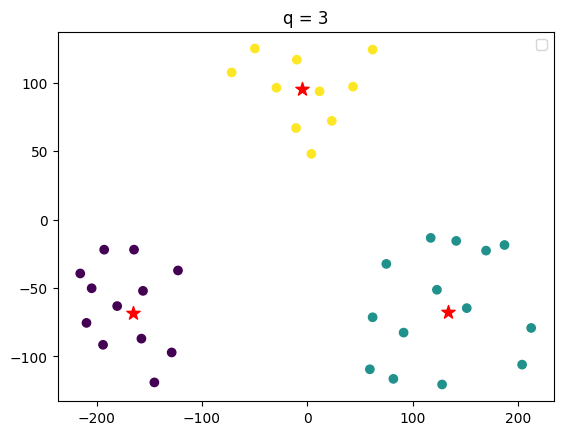

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(X[:,0], X[:,1], c = y)
for i in range(q):
  plt.scatter(prototype_vectors[i][0], prototype_vectors[i][1], s=100, c = 'red', marker = "*")

plt.legend()
plt.title(f"q = {q}")
plt.show()